In [ ]:
import numpy as np
from scipy import stats
import pandas as pd

In [ ]:
df = pd.read_csv('cleaned_data.csv')

In [ ]:
tech = df[df['Category'] == 'Technology']['Sales'].values
furn = df[df['Category'] == 'Furniture']['Sales'].values

In [ ]:
tech.sum(),furn.sum()

(np.float64(827455.86), np.float64(728658.5))

In [ ]:
# Levene test
lev_stat, lev_p = stats.levene(tech, furn)
print("Levene p:", lev_p)

Levene p: 0.00023477382125897453


In [ ]:
# Welch T-Test
t_stat, p_val = stats.ttest_ind(tech, furn, equal_var=False)
print("T-Statistic:", t_stat)
print("P-Value:", p_val)

T-Statistic: 3.7179085804247247
P-Value: 0.00020540196765309835


In [ ]:
# Cohen's d
d = (np.mean(tech) - np.mean(furn)) / np.sqrt((np.std(tech)**2 + np.std(furn)**2)/2)
print("Cohen's d:", d)

Cohen's d: 0.12218979696706063


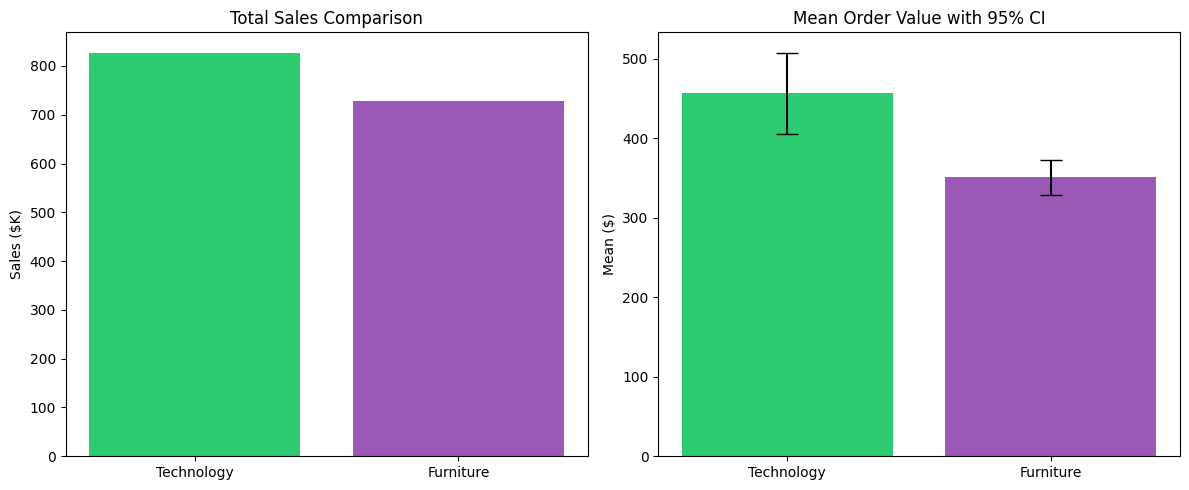

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
cats = ['Technology', 'Furniture']
totals = [827456, 728659]
ax1.bar(cats, [t/1000 for t in totals], color=['#2ecc71','#9b59b6'])
ax1.set_title('Total Sales Comparison')
ax1.set_ylabel('Sales ($K)')

# Mean + CI
means = [np.mean(tech), np.mean(furn)]
errs  = [stats.sem(tech)*1.96, stats.sem(furn)*1.96]
ax2.bar(cats, means, color=['#2ecc71','#9b59b6'], yerr=errs, capsize=8)
ax2.set_title('Mean Order Value with 95% CI')
ax2.set_ylabel('Mean ($)')

plt.tight_layout()
plt.savefig('charts.png', dpi=150)
plt.show()